# virchow2 cell vs niche - embedding interpretability

goal: turn the cell-vs-niche qc numbers into a visual story and probe what the 1280-d virchow2 space actually encodes.

sections:
1. load cached embeddings + labels (cell + niche)
2. umap 2x3 grid: {cell, niche} x {mc, morph, patient}
3. pca + concept probing: which pcs lock onto mc / morph / patient?
4. patient-architecture ablation: project out patient-correlated pcs, recompute batch_ratio + lp_mc

numbers being visualized (from `encoder_qc_cell_vs_niche.json`):
```
                cell     niche
within_sil_mc   0.071   0.120   <- niche wins, context encodes program
within_sil_mo   0.073   0.030   <- cell wins, single cell encodes compartment
lp_mc           19.0%   23.6%   <- niche wins
lp_morph        66.8%   57.1%   <- cell wins
batch_ratio     0.585   1.089   <- cell more cross-patient stable
```

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedGroupKFold
import umap

sns.set_theme(style='ticks', palette='Set2', context='notebook')

ROOT = Path('..').resolve().parent
EMB_DIR = ROOT / 'data' / 'embeddings'
BIO_DIR = EMB_DIR / 'biological_signals'
CACHE_DIR = EMB_DIR / '_interp_cache'
CACHE_DIR.mkdir(exist_ok=True)
SEED = 42
rng = np.random.RandomState(SEED)

## 1. loader with cache

the compare_cell_niche_qc.py loader shells to Rscript per subarray (~280 calls) to recover spot order. we cache the first pass to `.npz` so this notebook reruns instantly.

In [2]:
def load_encoder_bundle(dirname):
    cache = CACHE_DIR / f'{dirname}.npz'
    if cache.exists():
        z = np.load(cache, allow_pickle=True)
        return dict(
            X=z['X'],
            mc=z['mc'].tolist(),
            morph=z['morph'].tolist(),
            patients=z['patients'],
            subarrays=z['subarrays'],
        )

    enc_dir = EMB_DIR / dirname
    mc = pd.read_csv(BIO_DIR / 'mc_labels.tsv', sep='\t')
    morph = pd.read_csv(BIO_DIR / 'morphology_labels.tsv', sep='\t')
    morph['short'] = morph['subarray_id'].str.replace(r'^TNBC\d+_', '', regex=True)

    files = [f for f in sorted(enc_dir.glob('*.npy')) if not f.stem.endswith('_meta')]
    lookup = {}
    for f in files:
        parts = f.stem.split('_', 1)
        if len(parts) == 2 and parts[0].startswith('TNBC'):
            lookup[parts[1]] = (f, int(parts[0].replace('TNBC', '')))

    X_rows, mc_l, mo_l, pat_l, sub_l = [], [], [], [], []
    for i, (subarray, (path, patient)) in enumerate(lookup.items(), 1):
        emb = np.load(path)
        slide, pos = subarray.split('_')
        rdata = ROOT / 'data' / 'inputs' / 'byArray' / slide / pos / 'selection.RData'
        if not rdata.exists():
            continue
        r = subprocess.run(
            ['Rscript', '-e', f'load("{rdata}"); cat(rownames(cnts), sep="\\n")'],
            capture_output=True, text=True)
        spot_ids = [s for s in r.stdout.strip().split('\n') if s]
        if len(spot_ids) != emb.shape[0]:
            continue
        mc_sub = mc[mc['subarray'] == subarray].set_index('spot_id')
        mo_sub = morph[morph['short'] == subarray].set_index('spot_id')
        for j, sid in enumerate(spot_ids):
            mcl = mc_sub.loc[sid, 'megacluster'] if sid in mc_sub.index else None
            mol = mo_sub.loc[sid, 'dominant_5class'] if sid in mo_sub.index else None
            if mcl is None and mol is None:
                continue
            X_rows.append(emb[j])
            mc_l.append(mcl)
            mo_l.append(mol)
            pat_l.append(patient)
            sub_l.append(subarray)
        if i % 50 == 0:
            print(f'    {i}/{len(lookup)}')

    bundle = dict(
        X=np.array(X_rows, dtype=np.float32),
        mc=mc_l,
        morph=mo_l,
        patients=np.array(pat_l),
        subarrays=np.array(sub_l),
    )
    np.savez_compressed(
        cache,
        X=bundle['X'],
        mc=np.array(bundle['mc'], dtype=object),
        morph=np.array(bundle['morph'], dtype=object),
        patients=bundle['patients'],
        subarrays=bundle['subarrays'],
    )
    return bundle


print('loading cell...')
cell = load_encoder_bundle('virchow2_cell')
print('loading niche...')
niche = load_encoder_bundle('virchow2_niche')
print(f'cell  X: {cell["X"].shape}, patients: {len(set(cell["patients"]))}')
print(f'niche X: {niche["X"].shape}, patients: {len(set(niche["patients"]))}')

loading cell...
    50/280
    100/280
    150/280
    200/280
    250/280
loading niche...
    50/280
    100/280
    150/280
    200/280
    250/280
cell  X: (272839, 1280), patients: 94
niche X: (272839, 1280), patients: 94


## 2. umap 2x3 grid

subsample to ~25k spots per encoder (same indices) for tractable umap. color by mc (14 classes), morph (5 classes), patient (94 ids).

In [3]:
# shared subsample so cell and niche panels are comparable
N = min(25000, len(cell['X']), len(niche['X']))
assert len(cell['X']) == len(niche['X']), 'cell and niche must have identical spot order'
idx = rng.choice(len(cell['X']), N, replace=False)

mc_sub = np.array([cell['mc'][i] if cell['mc'][i] is not None else 'na' for i in idx])
mo_sub = np.array([cell['morph'][i] if cell['morph'][i] is not None else 'na' for i in idx])
pat_sub = cell['patients'][idx]

def run_umap(X):
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='cosine', random_state=SEED)
    return reducer.fit_transform(X)

print('umap cell...')
u_cell = run_umap(cell['X'][idx])
print('umap niche...')
u_niche = run_umap(niche['X'][idx])

umap cell...
umap niche...


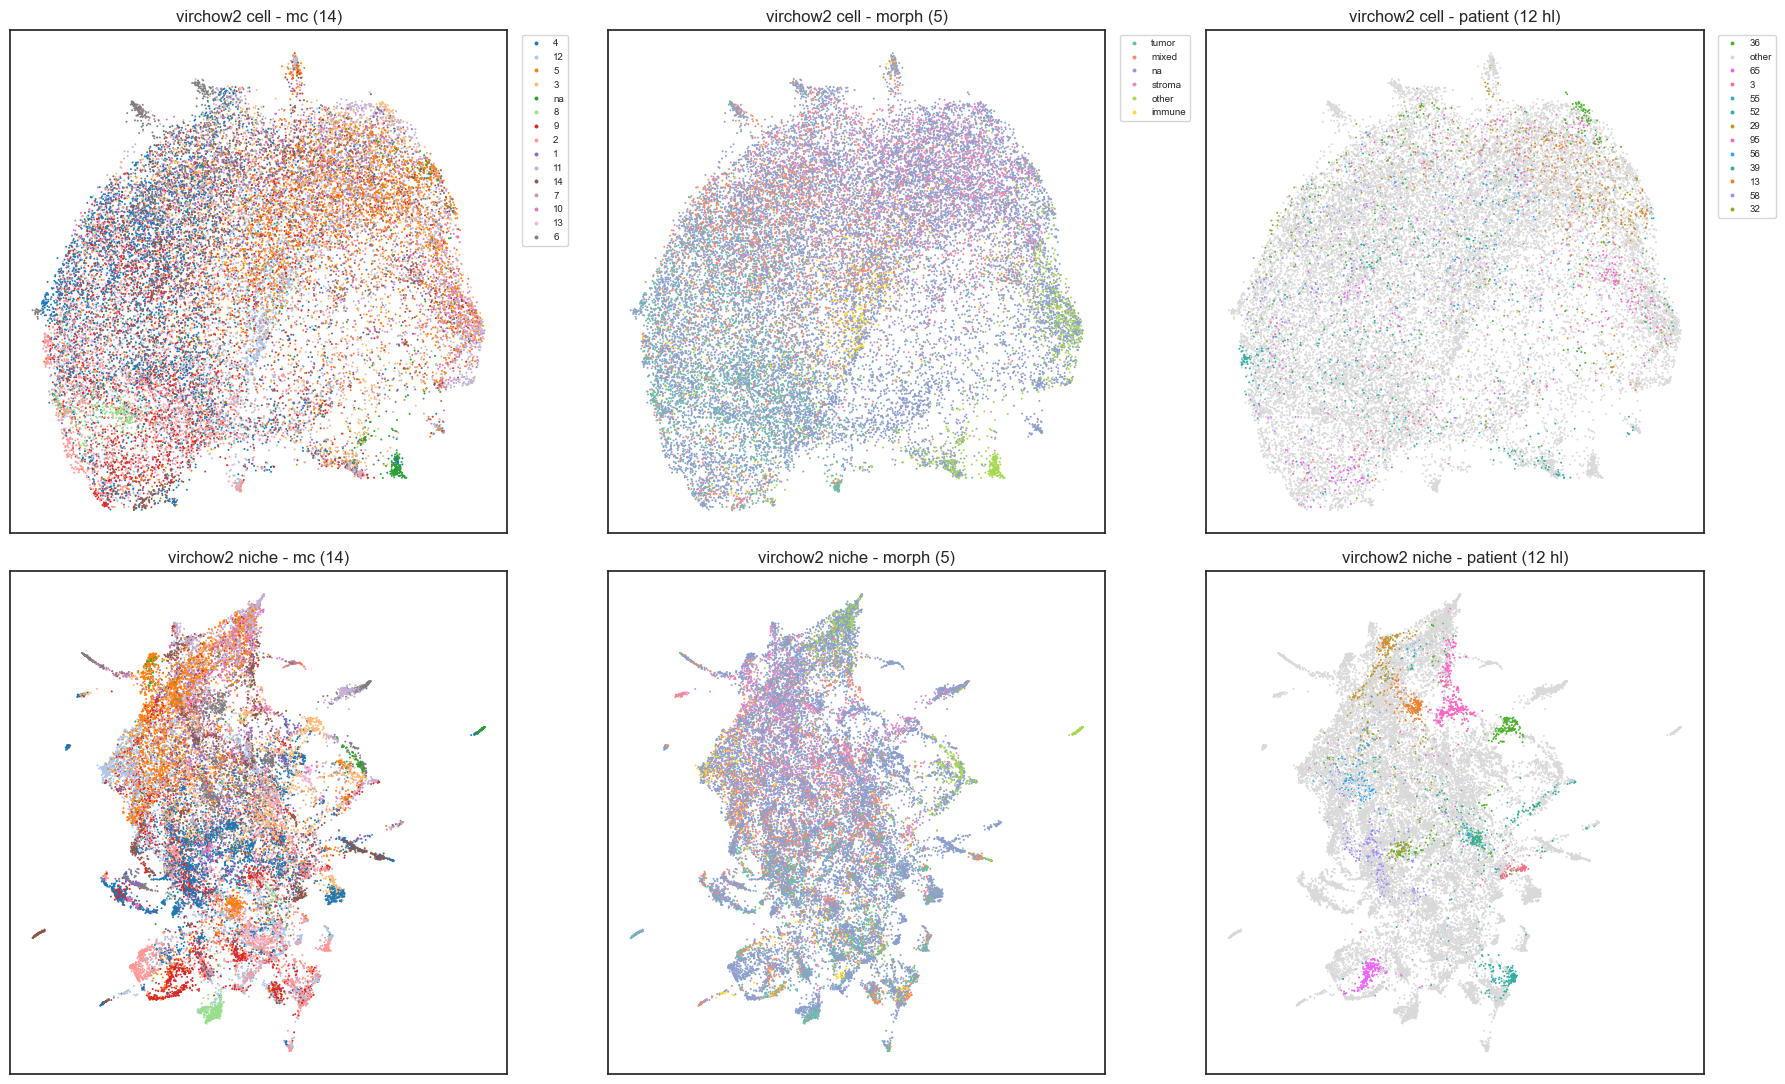

In [4]:
def scatter(ax, u, labels, title, palette, legend=False, s=2):
    df = pd.DataFrame({'x': u[:, 0], 'y': u[:, 1], 'label': labels})
    sns.scatterplot(
        data=df, x='x', y='y', hue='label',
        palette=palette, s=s, linewidth=0, ax=ax,
        legend='brief' if legend else False,
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])
    if legend:
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, markerscale=2)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
mc_palette = sns.color_palette('tab20', n_colors=len(set(mc_sub)))
mo_palette = sns.color_palette('Set2', n_colors=len(set(mo_sub)))
# patient: sample ~12 patients for legibility, grey others
unique_pat = np.unique(pat_sub)
highlight = set(rng.choice(unique_pat, min(12, len(unique_pat)), replace=False))
pat_display = np.array([str(p) if p in highlight else 'other' for p in pat_sub])
pat_palette = {str(p): c for p, c in zip(sorted(highlight), sns.color_palette('husl', len(highlight)))}
pat_palette['other'] = (0.85, 0.85, 0.85)

for row, (u, name) in enumerate([(u_cell, 'virchow2 cell'), (u_niche, 'virchow2 niche')]):
    scatter(axes[row, 0], u, mc_sub, f'{name} - mc (14)', mc_palette, legend=(row == 0))
    scatter(axes[row, 1], u, mo_sub, f'{name} - morph (5)', mo_palette, legend=(row == 0))
    scatter(axes[row, 2], u, pat_display, f'{name} - patient (12 hl)', pat_palette, legend=(row == 0))

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'embeddings' / 'virchow2_cell_vs_niche_umap.png', dpi=150, bbox_inches='tight')
plt.show()

### expected story
- mc column -> niche row should show tighter / more connected color regions (within_sil_mc 0.120 vs 0.071)
- morph column -> cell row should show sharper compartment boundaries (within_sil_morph 0.073 vs 0.030)
- patient column -> niche row should show visible patient-dominated blobs (batch_ratio 1.089 vs 0.585)

## 3. pca + concept probing

fit pca on each encoder, then ask for each of the top-20 pcs: how much variance does it explain in {mc, morph, patient}? we use eta-squared (categorical anova effect size) as the concept-lock score per pc.

In [5]:
def eta_squared(x, labels):
    # one-way anova effect size - fraction of pc variance explained by group means
    le = LabelEncoder()
    y = le.fit_transform(labels)
    grand = x.mean()
    ss_total = ((x - grand) ** 2).sum() + 1e-12
    ss_between = 0.0
    for c in np.unique(y):
        xc = x[y == c]
        ss_between += len(xc) * (xc.mean() - grand) ** 2
    return ss_between / ss_total

def concept_lock_table(bundle, k=20):
    X = bundle['X']
    mc = bundle['mc']
    mo = bundle['morph']
    pat = bundle['patients']
    # mask rows that have mc + morph both present for a fair comparison
    mask = np.array([(m is not None) and (o is not None) for m, o in zip(mc, mo)])
    Xm = X[mask]
    mcm = [mc[i] for i in range(len(mc)) if mask[i]]
    mom = [mo[i] for i in range(len(mo)) if mask[i]]
    patm = pat[mask]

    # subsample for speed
    if len(Xm) > 40000:
        s = rng.choice(len(Xm), 40000, replace=False)
        Xm = Xm[s]
        mcm = [mcm[i] for i in s]
        mom = [mom[i] for i in s]
        patm = patm[s]

    pca = PCA(n_components=k, random_state=SEED)
    Z = pca.fit_transform(Xm)
    rows = []
    for i in range(k):
        rows.append({
            'pc': i + 1,
            'var_expl': pca.explained_variance_ratio_[i],
            'eta2_mc': eta_squared(Z[:, i], mcm),
            'eta2_morph': eta_squared(Z[:, i], mom),
            'eta2_patient': eta_squared(Z[:, i], patm),
        })
    return pd.DataFrame(rows), pca, Z, mcm, mom, patm

print('pca cell...')
tbl_cell, pca_cell, Zc, mc_c, mo_c, pat_c = concept_lock_table(cell)
print('pca niche...')
tbl_niche, pca_niche, Zn, mc_n, mo_n, pat_n = concept_lock_table(niche)

pca cell...
pca niche...


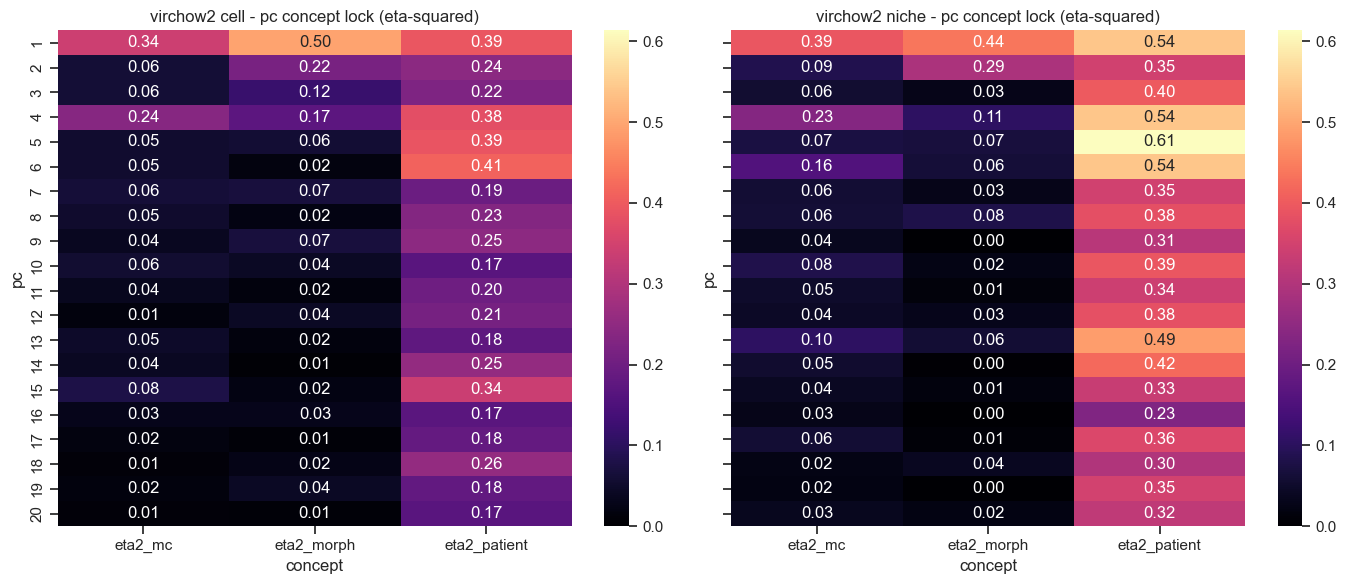


top patient-locked pcs (niche):
 pc  var_expl  eta2_patient  eta2_mc
  5  0.052365      0.613705 0.072920
  6  0.047183      0.540953 0.155382
  4  0.058367      0.540023 0.233573
  1  0.170967      0.539836 0.393084
 13  0.014802      0.487549 0.103179

top mc-locked pcs (niche):
 pc  var_expl  eta2_mc  eta2_patient
  1  0.170967 0.393084      0.539836
  4  0.058367 0.233573      0.540023
  6  0.047183 0.155382      0.540953
 13  0.014802 0.103179      0.487549
  2  0.094558 0.086051      0.346323


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, (tbl, name) in zip(axes, [(tbl_cell, 'virchow2 cell'), (tbl_niche, 'virchow2 niche')]):
    mat = tbl.set_index('pc')[['eta2_mc', 'eta2_morph', 'eta2_patient']]
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='magma', cbar=True, ax=ax,
                vmin=0, vmax=max(tbl_cell[['eta2_mc','eta2_morph','eta2_patient']].values.max(),
                                  tbl_niche[['eta2_mc','eta2_morph','eta2_patient']].values.max()))
    ax.set_title(f'{name} - pc concept lock (eta-squared)')
    ax.set_xlabel('concept')
    ax.set_ylabel('pc')
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'embeddings' / 'virchow2_pc_concept_lock.png', dpi=150, bbox_inches='tight')
plt.show()

print('\ntop patient-locked pcs (niche):')
print(tbl_niche.nlargest(5, 'eta2_patient')[['pc', 'var_expl', 'eta2_patient', 'eta2_mc']].to_string(index=False))
print('\ntop mc-locked pcs (niche):')
print(tbl_niche.nlargest(5, 'eta2_mc')[['pc', 'var_expl', 'eta2_mc', 'eta2_patient']].to_string(index=False))

## 4. patient-architecture ablation

hypothesis: niche's batch_ratio inflation (1.089 vs cell 0.585) lives in a small number of patient-locked pcs. if we project those out, does batch_ratio drop toward cell's without killing lp_mc?

procedure:
1. fit pca(n=50) on niche embeddings
2. rank pcs by eta2_patient, pick top-k
3. zero those components, reconstruct
4. recompute batch_ratio + lp_mc + cross_sil_mc

In [7]:
def batch_effect_ratio(X, patients):
    centroids = {}
    for pid in np.unique(patients):
        centroids[pid] = X[patients == pid].mean(axis=0)
    cmat = np.stack([centroids[p] for p in sorted(centroids)])
    inter = pdist(cmat, 'cosine').mean()
    intras = []
    for pid in np.unique(patients):
        Xp = X[patients == pid]
        c = Xp.mean(axis=0)
        norms = np.linalg.norm(Xp, axis=1) * np.linalg.norm(c) + 1e-12
        intras.append((1 - (Xp @ c) / norms).mean())
    return inter / np.mean(intras)

def lp_mc(X, mc_labels, patients):
    keep = [i for i, v in enumerate(mc_labels) if v is not None]
    X = X[keep]
    y = LabelEncoder().fit_transform([mc_labels[i] for i in keep])
    g = patients[keep]
    # cap per class
    sel = []
    for c in np.unique(y):
        idx_c = np.where(y == c)[0]
        if len(idx_c) > 500:
            idx_c = rng.choice(idx_c, 500, replace=False)
        sel.extend(idx_c)
    sel = np.array(sel)
    Xs, ys, gs = X[sel], y[sel], g[sel]
    gkf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
    accs = []
    for tr, te in gkf.split(Xs, ys, gs):
        sc = StandardScaler().fit(Xs[tr])
        clf = SGDClassifier(loss='log_loss', max_iter=500, random_state=SEED)
        clf.fit(sc.transform(Xs[tr]), ys[tr])
        accs.append(clf.score(sc.transform(Xs[te]), ys[te]))
    return np.mean(accs)

# fit fresh pca(50) on niche
Xn = niche['X']
pca50 = PCA(n_components=50, random_state=SEED)
Zn50 = pca50.fit_transform(Xn)

# rank pcs by patient eta2
eta_pat = np.array([eta_squared(Zn50[:, i], niche['patients']) for i in range(50)])
order = np.argsort(-eta_pat)
print('top-10 pcs by eta2_patient:', list(zip(order[:10] + 1, eta_pat[order[:10]].round(3))))

top-10 pcs by eta2_patient: [(np.int64(1), np.float32(0.528)), (np.int64(6), np.float32(0.483)), (np.int64(5), np.float32(0.44)), (np.int64(4), np.float32(0.435)), (np.int64(14), np.float32(0.404)), (np.int64(13), np.float32(0.357)), (np.int64(15), np.float32(0.315)), (np.int64(7), np.float32(0.307)), (np.int64(20), np.float32(0.306)), (np.int64(10), np.float32(0.305))]


In [8]:
ks = [0, 2, 5, 10, 20]
rows = []
for k in ks:
    if k == 0:
        Xk = Xn
    else:
        kill = order[:k]
        Zk = Zn50.copy()
        Zk[:, kill] = 0
        # reconstruct in original 1280d + add back the mean
        Xk = Zk @ pca50.components_ + pca50.mean_
    rows.append({
        'k_pcs_removed': k,
        'batch_ratio': batch_effect_ratio(Xk, niche['patients']),
        'lp_mc': lp_mc(Xk, niche['mc'], niche['patients']),
    })
ablation = pd.DataFrame(rows)
# add reference lines for cell
print(ablation.to_string(index=False))
print('\nreference: virchow2_cell batch_ratio=0.585, lp_mc=0.190')

 k_pcs_removed  batch_ratio    lp_mc
             0     1.088943 0.222327
             2     0.986553 0.186008
             5     0.843183 0.157318
            10     0.785251 0.121354
            20     0.503282 0.109387

reference: virchow2_cell batch_ratio=0.585, lp_mc=0.190


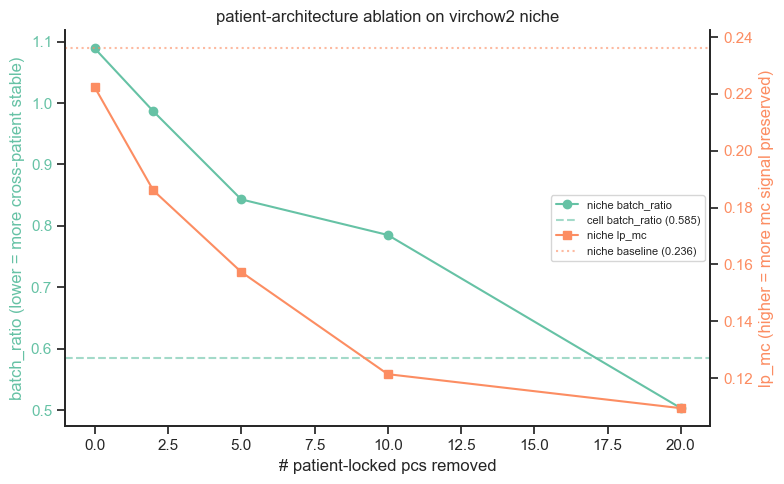

In [9]:
fig, ax1 = plt.subplots(figsize=(8, 5))
color_br = sns.color_palette('Set2')[0]
color_lp = sns.color_palette('Set2')[1]

ax1.plot(ablation['k_pcs_removed'], ablation['batch_ratio'], marker='o', color=color_br, label='niche batch_ratio')
ax1.axhline(0.585, ls='--', color=color_br, alpha=0.6, label='cell batch_ratio (0.585)')
ax1.set_xlabel('# patient-locked pcs removed')
ax1.set_ylabel('batch_ratio (lower = more cross-patient stable)', color=color_br)
ax1.tick_params(axis='y', labelcolor=color_br)

ax2 = ax1.twinx()
ax2.plot(ablation['k_pcs_removed'], ablation['lp_mc'], marker='s', color=color_lp, label='niche lp_mc')
ax2.axhline(0.236, ls=':', color=color_lp, alpha=0.6, label='niche baseline (0.236)')
ax2.set_ylabel('lp_mc (higher = more mc signal preserved)', color=color_lp)
ax2.tick_params(axis='y', labelcolor=color_lp)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=8)
ax1.set_title('patient-architecture ablation on virchow2 niche')
sns.despine(right=False)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'embeddings' / 'virchow2_niche_patient_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

### interpretation

read the ablation curve like this:
- if batch_ratio drops toward 0.585 AND lp_mc stays near 0.236 -> we found the patient-architecture subspace and niche is salvageable for cross-patient tasks via residualization
- if lp_mc collapses in lockstep with batch_ratio -> mc signal is entangled with patient architecture in niche, cannot separate with linear projection; must accept tradeoff or use cell for cross-patient
- if batch_ratio barely moves -> the inflation is spread across many pcs, not a few; need nonlinear methods (invariant risk minimization, domain adversarial)

next probing steps (not in this notebook):
- whitespace / h&e stain correlation: requires tile access, add once we cache patch rgb stats per spot
- sparse autoencoder on the top-50 pcs for fine-grained concept discovery
- tcav directions for specific concepts (tls, necrosis, tumor nests) once we have labeled example sets